In [33]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
import copy
import urllib.request
import json


# 1. O problema do *Multi-Armed Bandit*

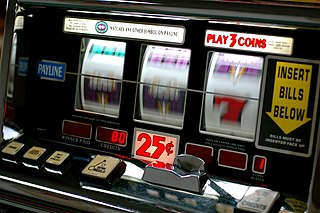

*Nota*: O conteúdo deste notebook é derivado do capítulo 2 de Sutton e Barto, "Reinforcement Learning, an Introduction".

Este é um problema clássico em aprendizagem por reforço.
O cenário que ilustra este problema é o de um jogador que tem a sua disposção uma máquina caça-niqueis especial, com várias alavancas.
A cada alavanca corresponde uma diferente probabilidade de vitória (claramente é um cenário bem distinto de um cassino real).

De modo abstrato, um agente pode escolher entre um número finito de ações $n$.
Para a cada ação correspondem recompensas aleatórias com distribuições distintas.

Embora de utilidade duvidosa para modelar jogos em cassinos, este é um modelo fundamental em aprendizado por reforço, e tem diversas aplicações práticas, como a pesquisa farmacêutica.

A classe ```kBanditFixoGaussiano``` modela uma dessas máquinas caça-níqueis.
As recompensas são obtidas de distribuições Gaussianas.

O construtor recebe dois parâmetros, ```recompensas``` e ```variancias```.
Estes são sequências com $k$ coeficientes. O $i$-gésimo coeficiente define o valor esperado e a variância da recompensa dada pela ação $i$.

O método ```recompensa``` recebe como parâmetro um inteiro $i$  de $0$ a $k-1$ e sorteia uma recompensa para a ação $i$.

O método ```k``` retorna o valor $k$ de ações possíveis.

O método ```melhor_ideal``` retorna o índice da ação de maior valor esperado.
Naturalmente um jogador *não* tem acesso a esta informação, mas este método será útil para avaliarmos a eficácia de diferentes estratégias para o problema


In [2]:
class kBanditFixoGaussiano():
  def __init__(self, recompensas, variancias):
    self._q = np.array(recompensas)
    self._v = np.array(variancias)

  def recompensa(self, acao):
    return np.random.normal(self._q[acao], self._v[acao])

  def melhor_acao(self):
    return np.argmax(self._q)

  def k(self):
    return len(self._q)


Vamos criar uma máquina com 10 braços, as recompensas esperadas são derivadas de uma distribuição gaussiana centrada em zero com variância unitária.
A máquina será armazenada na varíavel ```kbanditfixo```.
A variável ```valores_q_esperados``` contém a lista de valores esperados para cada recompensa.


In [3]:
np.random.seed(0)  # Fixa a semente para dar repetibilidade aos resultados
valores_q_esperados = np.random.normal(0,1,10)
kbanditfixo = kBanditFixoGaussiano(valores_q_esperados, np.ones(10))


In [4]:
def mostra_kbandit(b, n):
  collect = []
  for i in range(b.k()):
    c = [b.recompensa(i) for j in range(n)]
    collect.append(c)

  fig = plt.figure()

  ax = fig.add_axes([0,0,1,1])
  bp = ax.violinplot(collect, positions=range(b.k()))
  ax.set_xticks(range(b.k()))
  plt.show()


A figura a seguir mostra a distribuição esperada para cada ação:

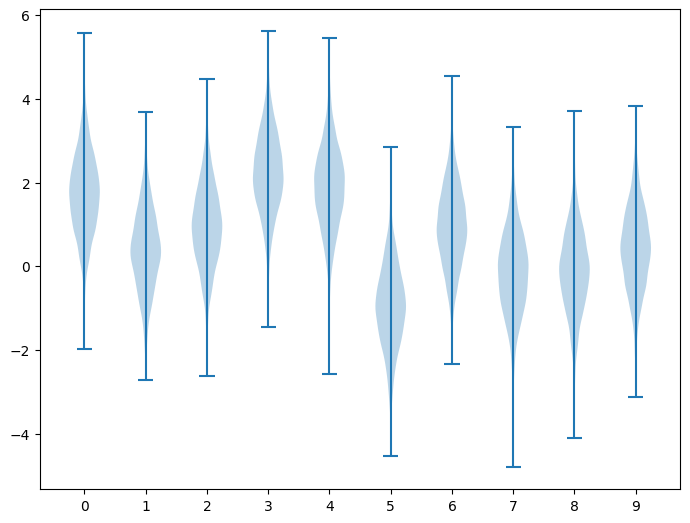


Melhor ação:3


In [5]:
mostra_kbandit(kbanditfixo, 4000)
print("\nMelhor ação:" + str(kbanditfixo.melhor_acao()))


Vamos modelar um jogador usando uma classe com 2 métodos:

O método ```escolhe_acao``` não recebe argumentos e retorna a ação que o jogador decide tomar.
O método ```informa_recompensa``` recebe como argumentos uma ação e a recompensa da ação.

A classe ```jogadorNulo``` implementa um jogador que sempre escolhe a *primeira* ação.
Note que ela ignora as chamadas a ```informa_recompensa```.

In [6]:
class jogadorNulo():
  def escolhe_acao(self):
    return 0

  def informa_recompensa(self, acao, resultado):
    pass



Vamos implementar mais dois jogadores triviais, um que sempre escolhe a *mesma* ação predeterminada, o outro que sempre escolhe uma ação aleatória:

In [7]:
class jogadorFixo(jogadorNulo):
  def __init__(self, acao):
    super().__init__()
    self._acao = acao

  def escolhe_acao(self):
    return self._acao


class jogadorAleatorio(jogadorNulo):
  def __init__(self, n):
    super().__init__()
    self._n = n

  def escolhe_acao(self):
    return np.random.choice(self._n)


A função ```testa_agente```simula uma série de iterações do jogador com a máquina.
O parâmetro ```kbandit``` recebe a máquina, o parâmetro ```agente``` recebe o jogador e o parâmetro ```iteracoes``` a quantidade de iterações a ser simulada.
A função retorna uma dupla com um vetor contendo a ação tomada em cada iteração e um vetor com a correspondente recompensa.

In [8]:
def testa_agente(kbandit, agente, iteracoes):
  resultados = []
  acoes = []
  for i in range(iteracoes):
    i = agente.escolhe_acao()
    r = kbandit.recompensa(i)
    agente.informa_recompensa(i, r)
    resultados.append(r)
    acoes.append(i)
  return (np.array(acoes, dtype=np.int32), np.array(resultados, dtype = np.float32))


Naturalmente, o valor médio da recompensa percebida pelo agente fixo para a ação $i$ tende ao valor esperado da recompensa $i$, enquanto que o valor médio da recompensa do agente aleatório tende à media dos valores esperados de cada recompensa:

In [9]:
print("Jogador fixos:")
for i in range(kbanditfixo.k()):
  res = testa_agente(kbanditfixo, jogadorFixo(i), 1000)[1]
  print("Jogador " + str(i) + " : Recompensas médias: " + str(np.mean(res)) + " Valor esperado: " + str(valores_q_esperados[i]))
res = testa_agente(kbanditfixo, jogadorAleatorio(kbanditfixo.k()), 1000)[1]
print("Jogador aleatório:")
print("Recompensas médias: " + str(np.mean(res)) + " Média dos Valores esperados: " + str(np.mean(valores_q_esperados)))


Jogador fixos:
Jogador 0 : Recompensas médias: 1.7700644 Valor esperado: 1.764052345967664
Jogador 1 : Recompensas médias: 0.4062415 Valor esperado: 0.4001572083672233
Jogador 2 : Recompensas médias: 0.96253747 Valor esperado: 0.9787379841057392
Jogador 3 : Recompensas médias: 2.2659903 Valor esperado: 2.240893199201458
Jogador 4 : Recompensas médias: 1.9284959 Valor esperado: 1.8675579901499675
Jogador 5 : Recompensas médias: -0.9829636 Valor esperado: -0.977277879876411
Jogador 6 : Recompensas médias: 0.93391186 Valor esperado: 0.9500884175255894
Jogador 7 : Recompensas médias: -0.19393246 Valor esperado: -0.1513572082976979
Jogador 8 : Recompensas médias: -0.13024035 Valor esperado: -0.10321885179355784
Jogador 9 : Recompensas médias: 0.37577853 Valor esperado: 0.41059850193837233
Jogador aleatório:
Recompensas médias: 0.79935277 Média dos Valores esperados: 0.7380231707288347


A abordagem de se usar a média dos valores de recompensa obtidos para se estimar a recompensa de uma determinada ação é bastante usada em aprendizado por refoço.

Seja $Q_t(a)$ a estimativa no instante $t$ de $q_*(a)$, o valor esperado da recompensa da ação $a$.

Se $A_i$ é a ação adotada no instante $i$, $R_i$ a recompensa no instante $i$ e $\mathbb{1}_{A_i = a}$ a *função indicadora* que vale $1$ se a ação $A_i$ é $a$ e $0$ caso contrário, então:

\begin{equation}
Q_t(a) = \frac{\sum_{i=1}^{t} {R_i \mathbb{1}_{A_i = a} }}{\sum_{i=1}^{t} {\mathbb{1}_{A_i = a}}}
\end{equation}

Note que esta expressão requer que a ação $a$ tenha sido experimentada ao menos *uma vez*.

Note que não é necessário para um agente manter o registro de todas as recompensas, nem recalcular a expressão acima a cada vez que for necessária a estimativa para a recompensa de um valor.

De fato, seja  $N_t(a) = \sum_{i=1}^{t} {\mathbb{1}_{A_i = a}}$ a quantidade de vezes em que a ação $a$ foi tomada até o instante $t$.

Suponha que a ação no instante $t$ tenha sido $a$.

Então evidentemente $N_t(a) = N_{t-1}(a) + 1$.

Por outro lado,

\begin{align}
Q_t(a) &= \frac{\sum_{i=1}^{t-1} {R_i \mathbb{1}_{A_i = a} } + R_t}{N_t(a)}\\
       &= \frac{N_{t-1}(a)Q_{t-1} + R_t}{N_t(a)}\\
       &= \frac{N_t(a)Q_{t-1}(a) - Q_t(a) + R_t}{N_t(a)}\\
       &= Q_{t-1}(a) + (R_t - Q_{t-1}(a)) \left(\frac{1}{N_t(a)}\right)
\end{align}

Assim, basta armazenar uma contagem para cada ação $N_t(a)$ para atualizar os valores de $Q_t(a)$.

A atualização de estimativas da forma

\begin{equation}
Q_t(a) = Q_{t-1}(a) + (R_t - Q_{t-1}(a))\alpha_t
\end{equation}

é bastante comum. O parâmetro $\alpha_t$ é a *taxa de aprendizado*.
Note que no caso do agente que estima recompensas pela média de todas as experiências anteriores, ele vale $1/N_t(A_t)$ e é estritamente decrescente.

## 1.1 Exploração *versus* Experimentação¹ e políticas $\epsilon$-gulosas.
(Do inglês "Exploitation vs. Exploration")

O jogador ideal para este problema é claramente o jogador que seleciona sempre a ação com a *maior* recompensa esperada.
Por outro lado, é possível estimar o valor esperado de uma determinada ação pela *média das recompensas* obtidas a cada vez que esta ação é selecionada.

Há então duas metas conflitantes: Por um lado, deseja-se tomar a ação que em um determinado momento parece ser a mais vantajosa (exploração).
Por outro, parece desejável selecionar ações alternativas para melhorar as estimativas de recompensa de cada (experimentação).

Uma política $\epsilon$-gulosa ($\epsilon$-greedy) é uma política que balanceia os dois comportamentos de exploração e experimentação.
Um agente seleciona com probabilidade $\epsilon$ uma ação aleatória e com probabilidade $1-\epsilon$ a ação que julga ser a melhor possível.




### Tarefa:
Implemente um jogador $\epsilon$-guloso que estima os valores de possíveis recompensas para cada ação usando a média dos valores de recompensas obtidos a cada vez que cada ação foi tomada.

Este jogador deve agir como o jogador aleatório com probabilidade $\epsilon$ e com probabilidade $1-\epsilon$ deve escolher a ação de $máxima$ estimativa $\underset{a}{\mbox{arg max}}Q_t(a)$.

Este jogador deve armazenar um vetor com a estimativa para cada ação e um vetor com a contagem de quantas vezes cada ação foi tomada.
Reimplemente a função ```informa_recompensa``` para atualizar estes vetores como descrito acima.

*Notas*


Quando mais de uma ação possuir a máxima estimativa, o jogador deve selecionar aleatoriamente entre estas. Aleḿ disso,
enquanto todas as ações não forem tomadas ao menos uma vez, não é possível estimar $Q_t(a)$ para todas as ações.
Podemos combinar estes dois fatores para simplificar a implementação.
Os valores iniciais do vetor que armazena $Q_t(a)$ serão valores aleatórios próximos de zero (por exemplo ```np.random.rand(self._n) * 1e-5```).
Estes valores iniciais são próximos de zero o suficiente para não enviesar a resposta mas garantem um desempate.

Complete a classe abaixo:

In [10]:
class agenteEpsilonGuloso():
  def __init__(self, n, epsilon):
    self._n = n
    self._e = epsilon
    self._q = np.random.rand(self._n) * 1e-5
    self._qn = np.zeros(n)

  def escolhe_acao(self):
    # Complete com seu código
    if np.random.random() < self._e:
      return np.random.choice(self._n)
    else:
      return np.argmax(self._q)

  def informa_recompensa(self, acao, resultado):
    # Complete com seu código
    self._qn[acao] += 1
    self._q[acao] = self._q[acao] + (resultado - self._q[acao]) * (1.0 / self._qn[acao])


Vamos avaliar como diferentes valores de $\epsilon$ afetam o desempenho de cada jogador:

In [11]:
tot_e01 = 0
tot_e001 = 0
tot_e0 = 0
correto_e01 = 0
correto_e001 = 0
correto_e0 = 0
experimentos = 2000
progresso = widgets.IntProgress(min=0, max=experimentos)
display(progresso)
for i in range(experimentos):
  res_teste = testa_agente(kbanditfixo, agenteEpsilonGuloso(kbanditfixo.k(), 0.1), 1000)
  tot_e01 += res_teste[1]
  correto_e01 += (res_teste[0]==kbanditfixo.melhor_acao()).astype(int)
  res_teste = testa_agente(kbanditfixo, agenteEpsilonGuloso(kbanditfixo.k(), 0.01), 1000)
  tot_e001 += res_teste[1]
  correto_e001 += (res_teste[0]==kbanditfixo.melhor_acao()).astype(int)
  res_teste = testa_agente(kbanditfixo, agenteEpsilonGuloso(kbanditfixo.k(), 0.0), 1000)
  tot_e0 += res_teste[1]
  correto_e0 += (res_teste[0]==kbanditfixo.melhor_acao()).astype(int)
  progresso.value = i
res=(np.array([tot_e01, tot_e001, tot_e0])/experimentos)


IntProgress(value=0, max=2000)

<>:3: SyntaxWarning: invalid escape sequence '\e'
<>:3: SyntaxWarning: invalid escape sequence '\e'
<>:3: SyntaxWarning: invalid escape sequence '\e'
<>:3: SyntaxWarning: invalid escape sequence '\e'
<>:3: SyntaxWarning: invalid escape sequence '\e'
<>:3: SyntaxWarning: invalid escape sequence '\e'
C:\Users\knd\AppData\Local\Temp\ipykernel_31124\2363830953.py:3: SyntaxWarning: invalid escape sequence '\e'
  axs[0].plot((np.array([tot_e01, tot_e001, tot_e0])/experimentos).T, label=["$\epsilon=0,1$", "$\epsilon=0,01$", "$\epsilon=0$"])
C:\Users\knd\AppData\Local\Temp\ipykernel_31124\2363830953.py:3: SyntaxWarning: invalid escape sequence '\e'
  axs[0].plot((np.array([tot_e01, tot_e001, tot_e0])/experimentos).T, label=["$\epsilon=0,1$", "$\epsilon=0,01$", "$\epsilon=0$"])
C:\Users\knd\AppData\Local\Temp\ipykernel_31124\2363830953.py:3: SyntaxWarning: invalid escape sequence '\e'
  axs[0].plot((np.array([tot_e01, tot_e001, tot_e0])/experimentos).T, label=["$\epsilon=0,1$", "$\epsilon=0,01$

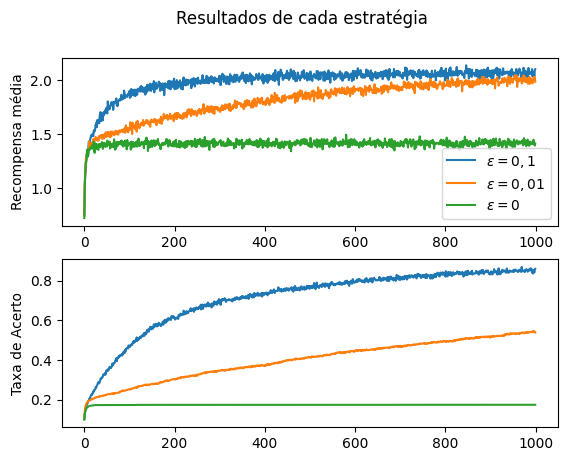

In [12]:
fig, axs = plt.subplots(2)
fig.suptitle('Resultados de cada estratégia')
axs[0].plot((np.array([tot_e01, tot_e001, tot_e0])/experimentos).T, label=["$\epsilon=0,1$", "$\epsilon=0,01$", "$\epsilon=0$"])
axs[0].set(ylabel='Recompensa média')
axs[1].plot((np.array([correto_e01, correto_e001, correto_e0])/experimentos).T)
axs[1].set(ylabel='Taxa de Acerto')
legend = axs[0].legend(loc='lower right')


## 1.2 Taxas de aprendizado e rastreamento de valores dinâmicos

Como observado, o valor $\alpha_t = 1/N_t(A_t)$ funciona como a taxa de aprendizado do jogador para a ação $A_t$.
É possível usar outros valores.
De fato, mostra-se que uma sequência $\alpha_i$ de taxas de aprendizado leva, no infninito, à convergência das estimativas $Q_t(a)$ para os valores reais $q_*(a)$ desde que:

\begin{align}
\sum_{i=1}^\infty \frac{1}{\alpha_i} &= +\infty\\
\sum_{i=1}^\infty \frac{1}{\alpha_i^2} &< +\infty
\end{align}

Nota-se que de acordo com estas definições, uma taxa de aprendizado *constante* não conduz à covergência.

De fato, se lembrarmos da definição da atualização, se $A_t = a$,

\begin{equation}
Q_t(a) = Q_{t-1}(a) + (R_t - Q_{t-1}(a))\alpha_t
\end{equation}

é claro que uma taxa $\alpha_i$ constante maior que zero faz com que as estimativas $Q_t(a)$ flutuem sempre que $R_i \neq Q_{t=1}(a)$.

Em alguns casos isso pode ser desejável.
Considere a situação em que deseja-se estimar continuamente os parâmetros de um processo que *variam no tempo*.

A classe ```kBanditDinamicoGaussiano``` modela uma máquina de caça-níqueis com braços múltiplos na qual as recompesas esperadas sofrem uma pequena alteração aleatória a cada ação.

In [13]:
class kBanditDinamicoGaussiano():
  def __init__(self, recompensas, variancias, d):
    self._q = np.array(recompensas)
    self._v = np.array(variancias)
    self._d = d

  def recompensa(self, acao):
    r = np.random.normal(self._q[acao], self._v[acao])
    self._q += np.random.normal(0, self._d, len(self._q))
    return r


  def melhor_acao(self):
    return np.argmax(self._q)

  def k(self):
    return len(self._q)


### Tarefa:

Complete a classe ```agenteEpsilonGulosoAlfa```.
Nesta classe você deve atualizar a estimatica esperada para cada ação de acordo com uma *taxa de aprendizagem* fixa.
A taxa está armazenada no atributo ```_alpha```.


In [14]:
class agenteEpsilonGulosoAlfa():
  def __init__(self, n, epsilon, alpha):
    self._n = n
    self._e = epsilon
    self._alpha = alpha
    self._q = np.random.rand(self._n) * 1e-5

  def escolhe_acao(self):
    if np.random.random() < self._e:
      return np.random.randint(self._n)
    return np.argmax(self._q)

  def informa_recompensa(self, acao, resultado):
    self._q[acao] = self._q[acao] + self._alpha * (resultado - self._q[acao])


Teste o desempenho de sua classe
(nota: o teste a seguir pode levar até 10 minutos!)

In [15]:
np.random.seed(0)  # Fixa a semente para dar repetibilidade aos resultados
valores_din = np.random.normal(0,1,10)
np.random.seed(0)
tot2_alpha = 0
tot2_e01 = 0
experimentos = 1000
progresso = widgets.IntProgress(min=0, max=experimentos)
display(progresso)
for i in range(experimentos):
  kbanditdinamico = kBanditDinamicoGaussiano(valores_din, np.ones(10), 0.1)
  res_teste = testa_agente(kbanditdinamico, agenteEpsilonGuloso(kbanditfixo.k(), 0.1), 10000)
  tot2_e01 += res_teste[1]
  kbanditdinamico = kBanditDinamicoGaussiano(valores_din, np.ones(10), 0.1)
  res_teste = testa_agente(kbanditdinamico, agenteEpsilonGulosoAlfa(kbanditdinamico.k(), 0.1, 0.2), 10000)
  tot2_alpha += res_teste[1]
  if i%20==0:
    progresso.value = i


IntProgress(value=0, max=1000)

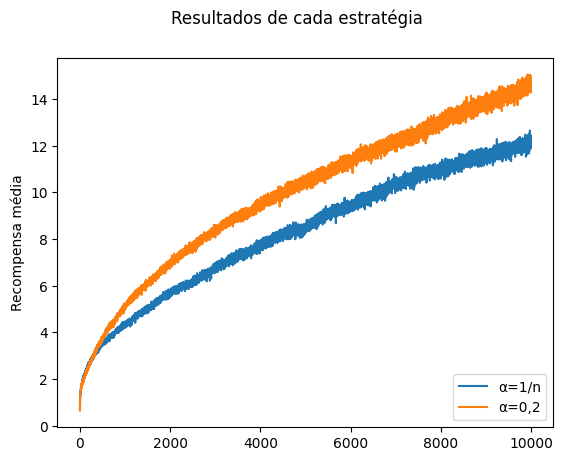

In [16]:
fig, axs = plt.subplots()
fig.suptitle('Resultados de cada estratégia')
axs.plot((np.array([tot2_e01, tot2_alpha])/experimentos).T, label=["α=1/n", "α=0,2"])
axs.set(ylabel='Recompensa média')
legend = axs.legend(loc='lower right')


# 2. O jogo-da-velha

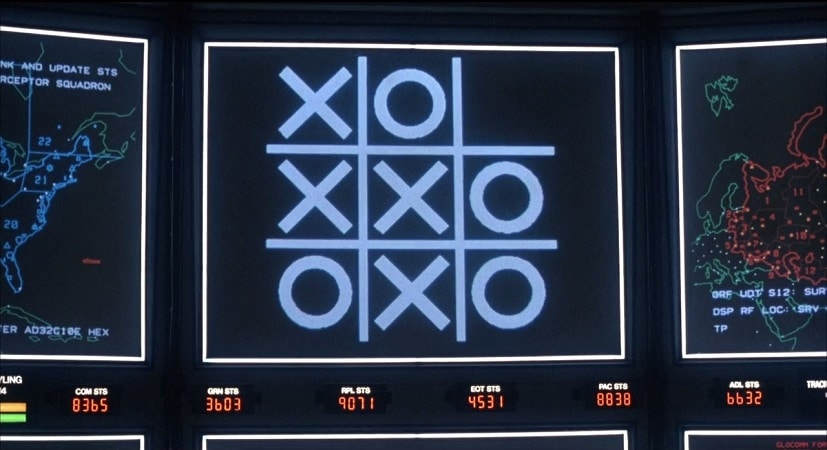

O jogo-da-velha é um conhecido jogo de papel e caneta.
Jogadores se alternam fazendo marcas em uma grade de 3x3.
O vencedor é o primeiro a conseguir fazer 3 marcas em uma mesma coluna, linha ou diagonal.

A classe ```JogoDaVelha``` implementa as regras do jogo.

O construtor recebe uma lista com dois símbolos, um para cada jogador.

O método ```estado_atual``` retorna uma lista de listas, cada uma correspondente a uma posição na grade do jogo.
A lista terá o símbolo do jogador que jogou em cada posição ou ```None```  se a posição ainda não foi ocupada.

O método ```jogador_atual``` retorna o símbolo do próximo jogador a fazer uma jogada.

O método ```aplica_jogada``` recebe como parâmetro uma lista de coordenadas da jogada, na sequência linha, coluna.
Os índices das linhas e colunas variam de 0 a 2.

O método ```jogadas_possiveis``` retorna uma lista com todas as jogadas possíveis.

O método ```jogo_continua``` retorna ```True``` se o jogo ainda não terminou, ou ```False```caso contrário.

O método ```vencedor``` retorna o símbolo do jogador que venceu o jogo, se este acabou em vitória de algum dos dois jogadores, ou ```None```se o jogo ainda continua ou se acabou em empate.

O método ```codigo_atual``` retorna um número inteiro único associado ao estado atual do jogo. A função deste método ficará mais clara a seguir.

In [47]:
class JogoDaVelha():
  def __init__(self, simbolos):
    if len(simbolos)!=2 or simbolos[0]==simbolos[1]:
      raise ValueError("Lista de Símbolos inválida")
    self._simbolos = list(simbolos)
    self._cols = 3
    self._lins = 3
    self._jogadas = 0
    self._jogo = [list([None]*self._cols) for i in range(self._lins)]
    self._codigojogo = 0
    # Armazena contagem de jogadas por coluna, linha, diagonal e jogador
    self._colunasporjogador = [[0]*self._cols, [0]*self._cols]
    self._linhasporjogador = [[0]*self._cols, [0]*self._cols]
    self._diagonalsporjogador = [[0,0], [0,0]]
    self._jogoContinua = True
    self._vencedor = -1

  def jogador_atual(self):
    return self._simbolos[self._jogadas & 1]

  def indice_jogador_atual(self):
    return self._jogadas & 1

  def estado_atual(self):
    return copy.deepcopy(self._jogo)

  def jogadas_possiveis(self):
    jogadas = []
    if self._jogoContinua:
      for i in range(self._lins):
        for j in range(self._cols):
          if self._jogo[i][j] is None:
            jogadas.append((i,j))
    return jogadas

  def indice_vencedor(self):
    return self._vencedor

  def vencedor(self):
    if self._vencedor>=0:
      return self._simbolos[self._vencedor]

  def _novo_codigo(self, jogada, jogador):
    return self._codigojogo | (1<<jogador)<<(2*(3*self._cols*jogada[0]+jogada[1]))

  def codigo_por_jogada(self, jogada):
    return self._novo_codigo(jogada, self._jogadas & 1)

  def codigo_atual(self):
    return self._codigojogo

  def aplica_jogada(self, jogada):
    if not self._jogoContinua:
      raise RuntimeError("Jogo encerrado")
    if self._jogo[jogada[0]][jogada[1]]:
      raise ValueError("Jogada impossível")
    jogador = self._jogadas & 1
    self._jogo[jogada[0]][jogada[1]] = self._simbolos[jogador]
    self._codigojogo = self._novo_codigo(jogada, jogador)
    self._jogadas += 1
    # Atualiza contagens e testa vitória
    self._colunasporjogador[jogador][jogada[0]]+=1
    if(self._colunasporjogador[jogador][jogada[0]]>=3):
      self._vencedor = jogador
      self._jogoContinua = False
    self._linhasporjogador[jogador][jogada[1]]+=1
    if(self._linhasporjogador[jogador][jogada[1]]>=3):
      self._vencedor = jogador
      self._jogoContinua = False
    if jogada[0]==jogada[1]:
      self._diagonalsporjogador[jogador][0]+=1
      if self._diagonalsporjogador[jogador][0]>=3:
        self._vencedor = jogador
        self._jogoContinua = False
    if jogada[0]==2-jogada[1]:
      self._diagonalsporjogador[jogador][1]+=1
      if self._diagonalsporjogador[jogador][1]>=3:
        self._vencedor = jogador
        self._jogoContinua = False
    if self._jogadas >= 9:
      self._jogoContinua = False

  def jogo_continua(self):
    return self._jogoContinua


Você pode testar a classe interativamente com o código a seguir:

In [48]:
def demonstra_jogodavelha():
  cols, rows = 3, 3
  jogo = JogoDaVelha(['╳', '⚪'])
  buttons = [widgets.Button(description=' ',disabled=False,buttom_style='',layout={'width': '35px', 'height': '35px'}) for i in range(cols*rows)]
  mensagem = widgets.Label(value="Aguardando jogada")
  rotulo_codigo = widgets.Label()
  rotulo_jogadas = widgets.Label()

  def atualiza_jogo():
    estado = jogo.estado_atual()
    acabou = not jogo.jogo_continua()
    for i in range(cols*rows):
      e = estado[i//rows][i%cols]
      if e:
        buttons[i].description = e
        buttons[i].disabled = True
      else:
        buttons[i].description = ' '
        buttons[i].disabled = acabou
    if acabou:
      if jogo.indice_vencedor() < 0:
        mensagem.value = "Empate"
      else:
        mensagem.value = "Vencedor: " + str(jogo.vencedor())
    else:
      mensagem.value = "Próxima jogada: "  + str(jogo.jogador_atual())
    rotulo_codigo.value = "Código da posição: " + str(jogo.codigo_atual())
    rotulo_jogadas.value = "Jogadas possíveis: " + str(jogo.jogadas_possiveis())

  def registra_jogada(i):
    jogo.aplica_jogada((i//rows,i%rows))
    atualiza_jogo()

  def reiniciar(b):
    nonlocal jogo
    jogo = JogoDaVelha(['╳', '⚪'])
    atualiza_jogo()

  for i, b in enumerate(buttons):
    b.on_click((lambda x: lambda b: registra_jogada(x))(i))
  reset = widgets.Button(description='Reiniciar')
  reset.on_click(reiniciar)
  display(reset)
  display(widgets.GridBox(buttons, layout=widgets.Layout(grid_template_columns="repeat("+str(cols)+", 40px)")))
  display(mensagem)
  display(rotulo_jogadas)
  display(rotulo_codigo)
  atualiza_jogo()
demonstra_jogodavelha()


Button(description='Reiniciar', style=ButtonStyle())

GridBox(children=(Button(description=' ', layout=Layout(height='35px', width='35px'), style=ButtonStyle()), Bu…

Label(value='Aguardando jogada')

Label(value='')

Label(value='')

Vamos implementar jogadores automáticos para o jogo-da-velha.

Um jogador trivial é o jogador que sempre escolhe a primeira jogada válida:
A classe jogador possui apenas um método, o ```escolhe_jogada```.
Este método recebe como parâmetro o jogo e devolve a jogada selecionada.

In [49]:
class jogador_trivial():
  def __init__(self):
    pass

  def escolhe_jogada(self, jogo):
    return jogo.jogadas_possiveis()[0]


In [50]:
def partida_interativa(oponente, comeca=True):
  cols=3
  rows=3
  jogo = JogoDaVelha(['╳', '⚪'])
  buttons = [widgets.Button(value = i, description=' ',disabled=False,buttom_style='',layout={'width': '35px', 'height': '35px'}) for i in range(cols*rows)]
  mensagem = widgets.Label(value="Aguardando jogada")

  def atualiza_jogo():
    if jogo.jogo_continua(): # Faz mais uma jogada do oponente
      jogada = oponente.escolhe_jogada(jogo)
      jogo.aplica_jogada(jogada)
    estado = jogo.estado_atual()
    acabou = not jogo.jogo_continua()
    for i in range(cols*rows):
      e = estado[i//rows][i%cols]
      if e:
        buttons[i].description = e
        buttons[i].disabled = True
      else:
        buttons[i].disabled = acabou
    if acabou:
      if jogo.indice_vencedor() < 0:
        mensagem.value = "Empate"
      elif (comeca and jogo.indice_vencedor()==0) or (not comeca and jogo.indice_vencedor()==1):
        mensagem.value = "Vitória"
      else:
        mensagem.value = "Derrota"

  def registra_jogada(i):
    jogo.aplica_jogada((i//rows,i%rows))
    atualiza_jogo()

  for i, b in enumerate(buttons):
    b.on_click((lambda x: lambda b: registra_jogada(x))(i))
  display(widgets.GridBox(buttons, layout=widgets.Layout(grid_template_columns="repeat("+str(cols)+", 40px)")))
  display(mensagem)
  if not comeca:
    atualiza_jogo()


Teste o jogador executando a célula a seguir:

In [21]:
partida_interativa(jogador_trivial(), True)


GridBox(children=(Button(description=' ', layout=Layout(height='35px', width='35px'), style=ButtonStyle()), Bu…

Label(value='Aguardando jogada')

Este não é um jogador muito interessante.
Podemos também implementar um jogador que escolhe jogadas aleatoriamente:

In [22]:
class jogadorAleatorio():
  def __init__(self):
    pass

  def escolhe_jogada(self, jogo):
    jogadas_possiveis = jogo.jogadas_possiveis()
    return jogadas_possiveis[np.random.choice(len(jogadas_possiveis))]


In [23]:
partida_interativa(jogadorAleatorio(), True)


GridBox(children=(Button(description=' ', layout=Layout(height='35px', width='35px'), style=ButtonStyle()), Bu…

Label(value='Aguardando jogada')

Um pouco mais interessante talvez, mas ainda assim longe de desafiar um jogador humano.

Existem alternativas mais sofisticadas para jogos, como $minmax$, mas estamos interessados aqui em um sistema que possa *aprender* a jogar.

# 2.1 Métodos tabulares e meio-estados

É possível aplicar com alguma adaptação os conceitos de processo decisórios de Markov ao jogo.
De fato, suponha que exista um oponente específico com uma estratégia fixa a cada partida.

Uma partida de jogo-da-velha contra um tal jogador pode ser modelado como um processo decisório de Markov no qual as ações são as jogadas possíveis e os estados terminais são aqueles que acabam em derrota, vitória ou empate.
Vamos aqui adotar uma recompensa de 1 em caso de vitória, -1 em caso de derrota e 0 em caso de empate.

Um método tabular de aprendizado é um método que tenta estimar a recompensa esperada para cada estado do sistema.
De posse de uma tablea destas, um jogador "guloso" poderia escolher a ação que leva à maior recompensa esperada.

Há um inconveniente com esta formulação: A estratégia requer um modelo do oponente.
Por exemplo, seja a posição:

$\begin{array}[ccc] {} X & X & O \\
O & X & O \\
- & - &  - \end{array}$

com o jogador 'X' a jogar.
Está claro que uma jogada na 3a linha, 2a coluna, leva ao fim de jogo com recompensa 1.
Mas qual é o valor de uma jogada na 3a linha, 1a coluna $(2, 0)$?
Resta ao oponente dois movimentos possíveis.
Caso o oponente responda com uma jogada na 3a linha, 2a coluna $(2,1)$, o jogador 'X' é obrigado a jogar na 3a linha, 3a coluna e ganha o jogo.
Caso o oponente responda com uma jogada na 3a linha, 3a coluna, a partida está perdida.

Neste exemplo, a recompensa esperada da ação $(2,0)$ contra o oponente aleatório é zero, enquanto que contra o oponente que escolhe a primeira jogada disponível é 1.

Seria útil "fatorar" a ação do oponete da tabela.
Uma abordagem comumente adotada em jogos é a do "meio-estado" (*half-step*).
Nesta estratégia, busca-se estimar a recompensa esperada no estado *antes* da ação do oponente.

Assim, de posse de estimativas de "meio-estados", um jogador "guloso" escolhe a jogada que leva ao meio-estado de máximo valor esperado.


# Tarefa:

Complete a implementação da classe ```JogadorGuloso```.

A classe contém um atributo ```_valores``` que corresponde a um dicionário.
As chaves do dicionário são códigos correspondentes a "meio-estados" (o estado do jogo antes do movimento do oponente) e o valor corresponde a uma estimativa da recompensa esperada ao final do jogo a partir deste estado.

Esta classe usa os códigos de posição fornecidos pela classe ```JogoDaVelha``` para indexar rapidamente o valor de uma posição.

Você deve escrever a implementação da função ```escolhe_jogada```.
Aqui você pode usar o método ```codigo_por_jogada``` da classe JogoDaVelha.
Este método recebe uma jogada e retorna qual seria o código correspondente da posição resultante.

*Atenção!* Não se espera que o atributo ```_valores``` contenha estimativas para todos os estados possíveis do jogo.
Se encontrar um estado que não está armazenado em ```_valores```, use o valor 0 como estimativa do valor.

In [28]:
class jogadorGuloso():
  def __init__(self, valores):
    self._valores = valores

  def escolhe_jogada(self, jogo):
    jogadas_possiveis = jogo.jogadas_possiveis()
    
    if not jogadas_possiveis:
      return None
      
    melhor_valor = float('-inf')
    melhor_jogada = None
    
    for jogada in jogadas_possiveis:
      codigo = jogo.codigo_por_jogada(jogada)
  
      valor = self._valores.get(codigo, 0)
      if valor > melhor_valor:
        melhor_valor = valor
        melhor_jogada = jogada
        
    return melhor_jogada


O arquivo em https://www.lsc.poli.usp.br/pece_ai/jogodavelha1300.json contém uma tabela pré-computada com valores estimados para algumas posições.
A célula abaixo carrega-o na variável ```estrategia1```.

In [25]:
response = urllib.request.urlopen("https://www.lsc.poli.usp.br/pece_ai/jogodavelha1300.json")
estrategia1 = json.loads(response.read(), object_hook=lambda d: {int(k) if k.lstrip('-').isdigit() else k: v for k, v in d.items()})


Você pode experimentar jogar contra esta estratégia:

In [27]:
partida_interativa(jogadorGuloso(estrategia1), True)


GridBox(children=(Button(description=' ', layout=Layout(height='35px', width='35px'), style=ButtonStyle()), Bu…

Label(value='Aguardando jogada')

Deve haver uma perceptível melhoria em comparação com o jogador aleatório.
De fato, podemos testar esse novo jogador contra o jogador aleatório.
O novo jogador deve ser capaz de ganhar um pouco mais do que 50% das partidas, mesmo jogando o segundo movimento.

In [29]:
p1 = jogadorAleatorio()
p2 = jogadorGuloso(estrategia1)
vitorias = 0
derrotas = 0
partidas = 8000
for i in range(partidas):
  jogo = JogoDaVelha(['X', 'O'])
  while jogo.jogo_continua():
    jogo.aplica_jogada(p1.escolhe_jogada(jogo))
    if jogo.jogo_continua():
      jogo.aplica_jogada(p2.escolhe_jogada(jogo))
  if jogo.indice_vencedor()==0:
    derrotas +=1
  elif jogo.indice_vencedor()==1:
    vitorias +=1
a_vitorias = int(100*(vitorias/partidas) + 0.5)
a_derrotas = int(100*(derrotas/partidas) + 0.5)
print("Resultado da estratégia contra o jogador aleatório:")
print("Vitórias: "+ str(a_vitorias) + "%")
print("Derrotas: "+ str(a_derrotas) + "%")
print("Empates: "+ str(100-a_derrotas-a_vitorias) + "%")


Resultado da estratégia contra o jogador aleatório:
Vitórias: 54%
Derrotas: 31%
Empates: 15%


# 2.2 Aprendizado de Monte-Carlo

Considerando a nomeclatura de processos decisórios de Markov, estabeleceremos qu a cada partida corresponde a um *episódio*.

Em cada episódio o jogo passa por "meio-estados" $S_0, S_1... S_{t_i}$, onde $t_i$ é o instante do estado terminal do $i$-gésimo episódio.
Ao final do episódio (quando o jogo termina), o jogador recebe uma recompensa $R_i$.

Naturalmente, apenas uma pequena parecela dos possíveis estados do jogo é visitada durante uma partida.
Vamos usar a recompensa ao final da partida para ajustar a estimativa dos estados visitados.

Seja $V_i(S_j)$ a estimativa ao final do $i$-gésimo episódio para o valor esperado do estado $S_j$

Ao término de um episódio podemos ajustar os valores para cada estado visitado percorrendo-os "de trás para frente".

Primeiro ajustamos a estimativa para o episódio final:

\begin{equation}
V_i(S_{t_i}) = V_{i-1}(S_{t_i}) + \alpha\left(V_{i}(R_i - V_{i-1}(S_{t_i})\right)
\end{equation}

A partir deste, ajustamos sequencialmente os episódios anteriores:

\begin{equation}
V_i(S_t) = V_{i-1}(S_t) + \alpha\left(V_{i}(S_{t+1} - V_{i}(S_t))\right)
\end{equation}

O parâmetro $\alpha$ é a taxa de aprendizado, e adota um papel similar ao do parâmetro $\alpha$ da seção 1.

Podemos assim criar um jogador que *aprende* com as partidas.
Para cada partida ele registra a sequência de meio-estados obtidos após cada jogada. Ao término da partida ele atualiza os valores estimados de cada meio-estado de acordo com as relações acima.

Novamente vamos adotar uma estratégia $\epsilon$-gulosa, na qual o jogador escolhe uma jogada puramente aleatória com probabilidade $\epsilon$ e com probabilidade $1-\epsilon$ ele escolhe a jogada que leva ao meio-estado de máximo valor.


### Tarefa:

Complete a implementação da classe ```jogadorAprendiz``` abaixo.
Assim como a classe ```JogadorGuloso```, ela recebe uma tabela de valores para cada posição (potencialmente nula).

A diferença é que ela deve *atualizar* valores desta tablea ao final de uma partida.

Para tanto ela conta com 3 novos métodos e 3 novos atributos.

O atributo ```_e``` é o valor de $\epsilon$ na estratégia $\epsilon$-gulosa.
O atributo ```_a``` é o valor da taxa de aprendizado $\alpha$.
O atributo ```_historico_posicoes``` é a sequência de "meio-estados" (ou seja, posições logo após o movimento do jogador) da partida atual.

O método ```confirma_movimento``` recebe como parâmetro a última jogada selecionada pelo jogador (presumivelmente a mesma retornada por ```escolhe_jogada``` e o jogo no qual a jogada foi feita.
Este método deve atualizar a sequência de estados da partida atual.

O método ```notifica_fim``` informa o término de uma partida. Ela recebe como parâmetro o jogo no estado final e o resultado (1 para vitória, -1 para derrota e 0 para empate).
Este método deve atualizar os valores dos estados presentes no histórico de posições de acordo com as regras vistas acima.

O método ```reset``` apaga o histórico atual de movimentos.

In [51]:
class jogadorAprendiz():
  def __init__(self, e, alpha, valores = None):
    self._valores = {} if valores is None else valores
    self._e = e
    self._alpha = alpha
    self._historico_posicoes = []

  def reset(self):
    self._historico_posicoes = []

  def _valor_posicao(self, codigo):
    if codigo in self._valores:
      return self._valores[codigo]
    else:
      return 0

  def _atribui_valor_posicao(self, codigo, valor):
      self._valores[codigo] = valor

  def escolhe_jogada(self, jogo):
    jogadas_possiveis = jogo.jogadas_possiveis()
    
    # Com probabilidade e, escolhe uma jogada aleatória (exploração)
    if np.random.random() < self._e:
        return jogadas_possiveis[np.random.randint(0, len(jogadas_possiveis))]
    
    # Com probabilidade 1-e, escolhe a jogada com maior valor estimado (aproveitamento)
    melhor_valor = float('-inf')
    melhores_jogadas = []
    
    for jogada in jogadas_possiveis:
        jogo_temp = copy.deepcopy(jogo)
        jogo_temp.aplica_jogada(jogada)
        valor = self._valor_posicao(jogo_temp.codigo_atual())
        
        if valor > melhor_valor:
            melhor_valor = valor
            melhores_jogadas = [jogada]
        elif valor == melhor_valor:
            melhores_jogadas.append(jogada)
    
    return melhores_jogadas[np.random.randint(0, len(melhores_jogadas))]

  def confirma_movimento(self, jogo, jogada):
    codigo = jogo.codigo_atual()
    self._historico_posicoes.append(codigo)

  def notifica_fim(self, jogo, resultado):
    if not self._historico_posicoes:
        return
    
    if resultado == 0:  # Empate
        valor_final = 0.5
    elif resultado == 1:  # Vitória
        valor_final = 1.0
    else:  # Derrota
        valor_final = 0.0
    
    valor_atual = valor_final
    
    # Atualiza os valores estimados para cada posição no histórico, de trás para frente
    for codigo in reversed(self._historico_posicoes):
        valor_antigo = self._valor_posicao(codigo)
        novo_valor = valor_antigo + self._alpha * (valor_atual - valor_antigo)
        self._atribui_valor_posicao(codigo, novo_valor)
        valor_atual = novo_valor
    
    self.reset()


Essa classe pode aprender a jogar sozinha.
Ainda assim é necessário um número razoável de partidas até que ela desenvolva uma estratégia competente.

É possível no entanto fazer essa classe *jogar contra ela mesma*.

A função abaixo simula uma partida entre dois jogadores, chamando os métodos ```confirma_movimento``` e ```notifica_fim```.

In [52]:
def partidaTreino(j1, j2):
  jogadores = [j1, j2]
  jogo = JogoDaVelha(['X', 'O'])
  while jogo.jogo_continua():
    jogador = jogo.indice_jogador_atual()
    jogada = jogadores[jogador].escolhe_jogada(jogo)
    jogo.aplica_jogada(jogada)
    jogadores[jogador].confirma_movimento(jogo, jogada)
  if jogo.indice_vencedor() < 0:
    jogadores[0].notifica_fim(jogo, 0)
    jogadores[1].notifica_fim(jogo, 0)
  else:
    jogadores[jogo.indice_vencedor()].notifica_fim(jogo, 1)
    jogadores[1-jogo.indice_vencedor()].notifica_fim(jogo, -1)


O código abaixo executa 300000 partidas entre dois jogadores e armazena o resultado no dicionário ```estrategia2```.

Observe que os dois jogadores *sempre* vão atualizar posições *distintas*, de modo que eles podem compartilhar o mesmo dicionário.

In [53]:
estrategia2 = {}
partidas = 300000
progresso = widgets.IntProgress(min=0, max=partidas)
jogadortreino1 = jogadorAprendiz(0.2, 0.1, estrategia2)
jogadortreino2 = jogadorAprendiz(0.2, 0.1, estrategia2)
display(progresso)
for i in range(partidas):
  partidaTreino(jogadortreino1, jogadortreino2)
  jogadortreino1.reset()
  jogadortreino2.reset()
  if i%200 == 0:
    progresso.value=i
progresso.value=i


IntProgress(value=0, max=300000)

Teste o desempenho desta estratégia jogando contra o jogador guloso.

In [59]:
partida_interativa(jogadorGuloso(estrategia2), True)


GridBox(children=(Button(description=' ', layout=Layout(height='35px', width='35px'), style=ButtonStyle()), Bu…

Label(value='Aguardando jogada')

Teste o desempenho do jogador aprendiz contra o jogador aleatório:

In [60]:
p1 = jogadorAleatorio()
p2 = jogadorGuloso(estrategia2)
vitorias = 0
derrotas = 0
partidas = 8000
for i in range(partidas):
  partida = []
  jogo = JogoDaVelha(['X', 'O'])
  while jogo.jogo_continua():
    jogo.aplica_jogada(p1.escolhe_jogada(jogo))
    partida.append(jogo.estado_atual())
    if jogo.jogo_continua():
      jogo.aplica_jogada(p2.escolhe_jogada(jogo))
      partida.append(jogo.estado_atual())
  if jogo.indice_vencedor()==0:
    derrotas +=1
  elif jogo.indice_vencedor()==1:
    vitorias +=1
a_vitorias = int(100*(vitorias/partidas) + 0.5)
a_derrotas = int(100*(derrotas/partidas) + 0.5)
print("Resultado da estratégia contra o jogador aleatório:")
print("Vitórias: "+ str(a_vitorias) + "%")
print("Derrotas: "+ str(a_derrotas) + "%")
print("Empates: "+ str(100-a_derrotas-a_vitorias) + "%")


Resultado da estratégia contra o jogador aleatório:
Vitórias: 88%
Derrotas: 2%
Empates: 10%
